In [34]:
# ============================================
# PRODIGY INFOTECH - DATA SCIENCE
# TASK 02: Exploratory Data Analysis
# ============================================

print("\nObjective:")
print("""
To perform data cleaning and exploratory data analysis on the Titanic dataset.
The analysis aims to explore relationships between different variables and
identify patterns and trends that influenced passenger survival.
""")

print("\nDataset Description:")
print("""
The dataset contains information about passengers aboard the Titanic,
including passenger class, name, gender, age, number of siblings/spouses,
number of parents/children, ticket, fare, cabin, port of embarkation,
and survival status.
""")


Objective:

To perform data cleaning and exploratory data analysis on the Titanic dataset.
The analysis aims to explore relationships between different variables and
identify patterns and trends that influenced passenger survival.


Dataset Description:

The dataset contains information about passengers aboard the Titanic,
including passenger class, name, gender, age, number of siblings/spouses,
number of parents/children, ticket, fare, cabin, port of embarkation,
and survival status.



In [35]:
# 1. Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
# --------------------------------------------
# 2. Upload the Titanic dataset
# --------------------------------------------

from google.colab import files

uploaded = files.upload()

# Get the uploaded CSV filename
csv_filename = list(uploaded.keys())[0]

print("Uploaded file:", csv_filename)


# --------------------------------------------
# 3. Load the dataset
# --------------------------------------------

df = pd.read_csv(csv_filename)

print("\nDataset loaded successfully!")

Saving train.csv to train (1).csv
Uploaded file: train (1).csv

Dataset loaded successfully!


In [37]:
# --------------------------------------------
# 4. Display first 5 rows
# --------------------------------------------

print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [38]:
# --------------------------------------------
# 5. Display dataset information
# --------------------------------------------

print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [39]:
# --------------------------------------------
# 6. Display dataset shape
# --------------------------------------------

print("\nDataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset Shape:
Rows: 891
Columns: 12


In [40]:
# --------------------------------------------
# 7. Display column names
# --------------------------------------------

print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [41]:
# --------------------------------------------
# 8. Check missing values
# --------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [42]:
# --------------------------------------------
# 9. Check duplicate rows
# --------------------------------------------

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
0


In [43]:
# --------------------------------------------
# 10. Check data types
# --------------------------------------------

print("\nData Types:")
print(df.dtypes)


Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [44]:
# --------------------------------------------
# 11. Handle missing values in Age
# --------------------------------------------

median_age = df["Age"].median()

df["Age"] = df["Age"].fillna(median_age)

print("\nMissing Age values after cleaning:")
print(df["Age"].isnull().sum())


Missing Age values after cleaning:
0


In [45]:
# --------------------------------------------
# 12. Handle missing values in Embarked
# --------------------------------------------

most_common_embarked = df["Embarked"].mode()[0]

df["Embarked"] = df["Embarked"].fillna(most_common_embarked)

print("\nMissing Embarked values after cleaning:")
print(df["Embarked"].isnull().sum())


Missing Embarked values after cleaning:
0


In [46]:
# --------------------------------------------
# 13. Remove Cabin column
# --------------------------------------------

df = df.drop(columns=["Cabin"])

print("\nCabin column removed because it contains a large number of missing values.")


Cabin column removed because it contains a large number of missing values.


In [47]:
# --------------------------------------------
# 14. Verify missing values after cleaning
# --------------------------------------------

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [48]:
# --------------------------------------------
# 15. Descriptive Statistics
# --------------------------------------------

print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [49]:
# --------------------------------------------
# 16. Survival Count
# --------------------------------------------

print("\nSurvival Count:")
print(df["Survived"].value_counts())

print("\nSurvival Percentage:")
print(df["Survived"].value_counts(normalize=True) * 100)


Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


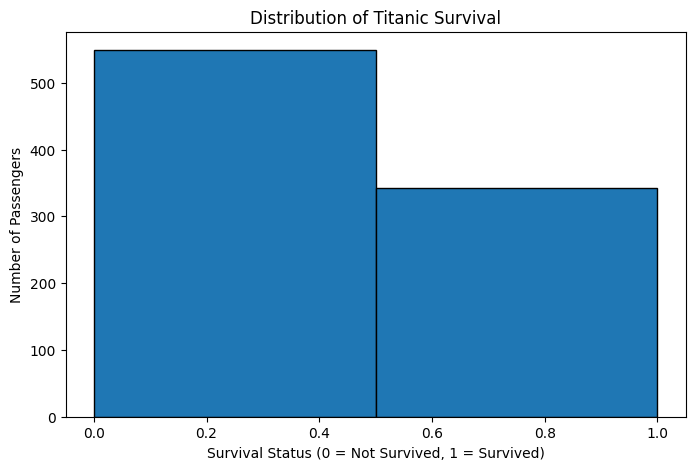

In [50]:
# --------------------------------------------
# 17. Survival Distribution
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(df["Survived"], bins=2, edgecolor="black")

plt.xlabel("Survival Status (0 = Not Survived, 1 = Survived)")
plt.ylabel("Number of Passengers")
plt.title("Distribution of Titanic Survival")

plt.show()

In [51]:
# --------------------------------------------
# 18. Survival by Gender
# --------------------------------------------

print("\nSurvival by Gender:")
survival_by_gender = pd.crosstab(df["Sex"], df["Survived"])

display(survival_by_gender)


Survival by Gender:


Survived,0,1
Sex,,
female,81,233
male,468,109


In [52]:
# --------------------------------------------
# 19. Survival Percentage by Gender
# --------------------------------------------

survival_percentage_gender = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

print("\nSurvival Percentage by Gender:")
display(survival_percentage_gender)


Survival Percentage by Gender:


Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


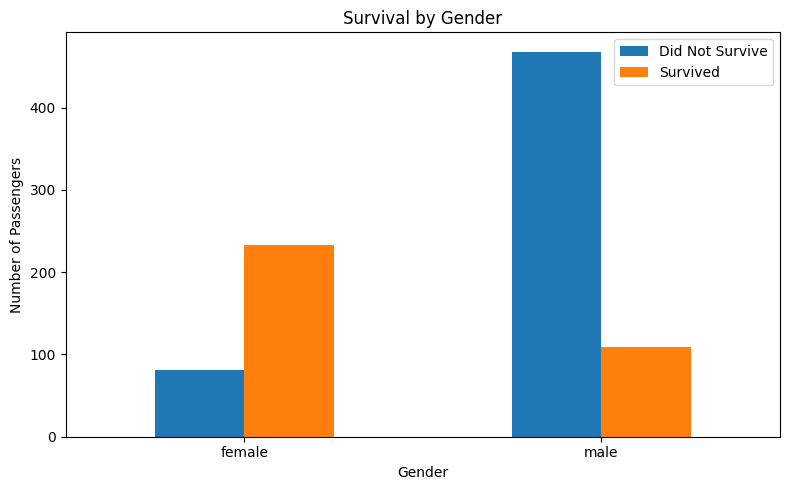

In [53]:
# --------------------------------------------
# 20. Survival by Gender Visualization
# --------------------------------------------

survival_by_gender.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.title("Survival by Gender")
plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])

plt.tight_layout()
plt.show()

In [54]:
# --------------------------------------------
# 21. Survival by Passenger Class
# --------------------------------------------

print("\nSurvival by Passenger Class:")

survival_by_class = pd.crosstab(
    df["Pclass"],
    df["Survived"]
)

display(survival_by_class)


Survival by Passenger Class:


Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [55]:
# --------------------------------------------
# 22. Survival Percentage by Passenger Class
# --------------------------------------------

survival_percentage_class = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

print("\nSurvival Percentage by Passenger Class:")
display(survival_percentage_class)


Survival Percentage by Passenger Class:


Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


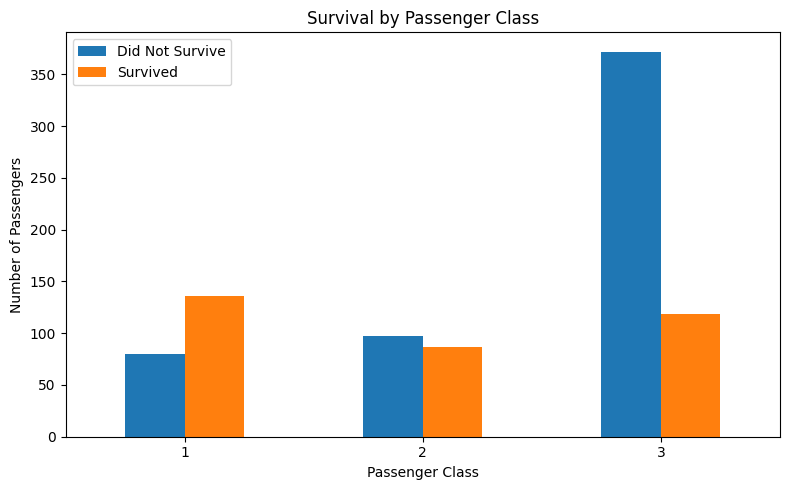

In [56]:
# --------------------------------------------
# 23. Survival by Passenger Class Visualization
# --------------------------------------------

survival_by_class.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Survival by Passenger Class")
plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])

plt.tight_layout()
plt.show()

In [57]:
# --------------------------------------------
# 24. Create Age Groups
# --------------------------------------------

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

print("\nAge Group Distribution:")
print(df["AgeGroup"].value_counts().sort_index())


Age Group Distribution:
AgeGroup
Child           69
Teenager        70
Young Adult    535
Adult          195
Senior          22
Name: count, dtype: int64


In [58]:
# --------------------------------------------
# 25. Survival Percentage by Age Group
# --------------------------------------------

survival_by_age = pd.crosstab(
    df["AgeGroup"],
    df["Survived"],
    normalize="index"
) * 100

print("\nSurvival Percentage by Age Group:")
display(survival_by_age)


Survival Percentage by Age Group:


Survived,0,1
AgeGroup,,
Child,42.028986,57.971014
Teenager,57.142857,42.857143
Young Adult,64.672897,35.327103
Adult,60.000000,40.000000
Senior,77.272727,22.727273


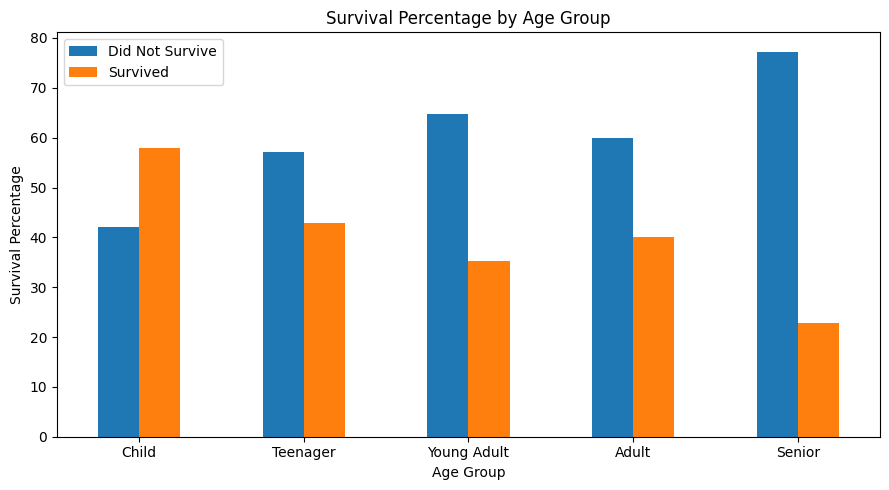

In [59]:
# --------------------------------------------
# 26. Survival by Age Group Visualization
# --------------------------------------------

survival_by_age.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Age Group")
plt.ylabel("Survival Percentage")
plt.title("Survival Percentage by Age Group")
plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])

plt.tight_layout()
plt.show()

In [60]:
# --------------------------------------------
# 27. Fare Analysis
# --------------------------------------------

print("\nAverage Fare by Survival Status:")

average_fare = df.groupby("Survived")["Fare"].mean()

print(average_fare)


Average Fare by Survival Status:
Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


/tmp/ipykernel_2385/44110208.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


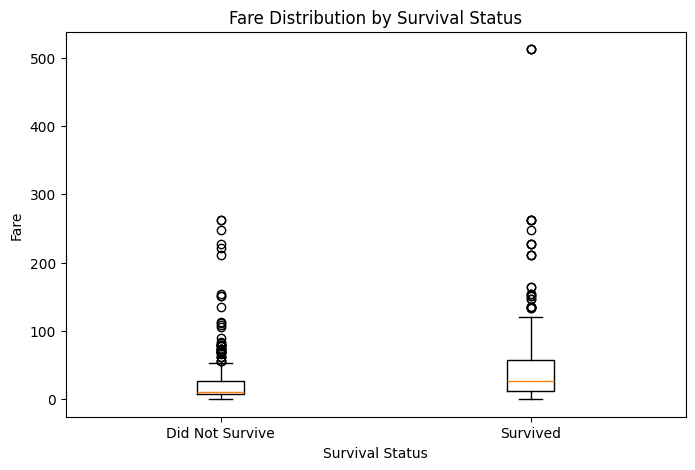

In [61]:
# --------------------------------------------
# 28. Fare Distribution by Survival Status
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.boxplot(
    [df[df["Survived"] == 0]["Fare"],
     df[df["Survived"] == 1]["Fare"]],
    labels=["Did Not Survive", "Survived"]
)

plt.xlabel("Survival Status")
plt.ylabel("Fare")
plt.title("Fare Distribution by Survival Status")

plt.show()

In [62]:
# --------------------------------------------
# 29. Correlation Analysis
# --------------------------------------------

numeric_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

correlation_matrix = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
display(correlation_matrix)


Correlation Matrix:


,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


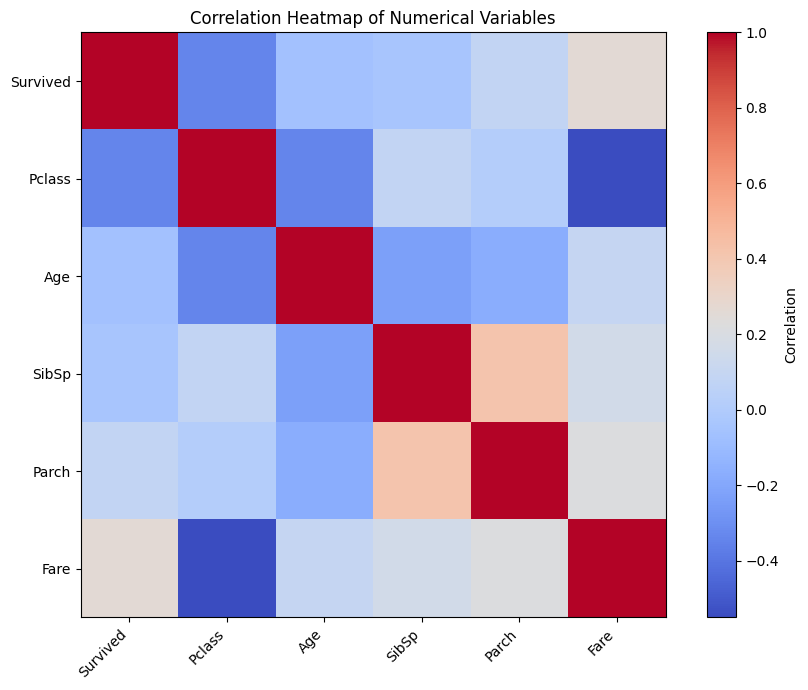

In [63]:
# --------------------------------------------
# 30. Correlation Heatmap
# --------------------------------------------

plt.figure(figsize=(9, 7))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="none")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

In [64]:
# --------------------------------------------
# 31. Key Findings
# --------------------------------------------

print("\nKey Findings:")
print("""
1. Out of 891 passengers, 342 (38.38%) survived, while
   549 (61.62%) did not survive.

2. Female passengers had a much higher survival rate
   (74.20%) compared with male passengers (18.89%).

3. Passenger class was strongly associated with survival.
   First-class passengers had the highest survival rate
   (62.96%), while third-class passengers had the lowest
   survival rate (24.24%).

4. Children had the highest survival rate among the age
   groups analyzed (57.97%), while seniors had the lowest
   (22.73%).

5. Passengers who survived paid a higher average fare
   (48.40) compared with passengers who did not survive
   (22.12).

6. Correlation analysis shows that Pclass and Fare had the
   strongest relationships with Survived among the numerical
   variables analyzed.
""")


Key Findings:

1. Out of 891 passengers, 342 (38.38%) survived, while
   549 (61.62%) did not survive.

2. Female passengers had a much higher survival rate
   (74.20%) compared with male passengers (18.89%).

3. Passenger class was strongly associated with survival.
   First-class passengers had the highest survival rate
   (62.96%), while third-class passengers had the lowest
   survival rate (24.24%).

4. Children had the highest survival rate among the age
   groups analyzed (57.97%), while seniors had the lowest
   (22.73%).

5. Passengers who survived paid a higher average fare
   (48.40) compared with passengers who did not survive
   (22.12).

6. Correlation analysis shows that Pclass and Fare had the
   strongest relationships with Survived among the numerical
   variables analyzed.



In [65]:
# --------------------------------------------
# 32. Conclusion
# --------------------------------------------

print("\nConclusion:")
print("""
The exploratory data analysis of the Titanic dataset reveals
clear patterns in passenger survival. Gender, passenger class,
age group, and fare were associated with differences in survival
rates. Female passengers and first-class passengers had notably
higher survival rates, while male and third-class passengers had
lower survival rates.

The analysis also showed that passengers who survived generally
paid higher fares. Correlation analysis supported the presence of
relationships between survival, passenger class, and fare.

Overall, the EDA demonstrates how data cleaning, descriptive
statistics, and visualization can be used to identify meaningful
patterns and relationships within a dataset.
""")


Conclusion:

The exploratory data analysis of the Titanic dataset reveals
clear patterns in passenger survival. Gender, passenger class,
age group, and fare were associated with differences in survival
rates. Female passengers and first-class passengers had notably
higher survival rates, while male and third-class passengers had
lower survival rates.

The analysis also showed that passengers who survived generally
paid higher fares. Correlation analysis supported the presence of
relationships between survival, passenger class, and fare.

Overall, the EDA demonstrates how data cleaning, descriptive
statistics, and visualization can be used to identify meaningful
patterns and relationships within a dataset.

